# Associar a conta do Google Drive com o Colab Notebook


In [ ]:
from google . colab import drive
drive.mount('/content/gdrive')
# List contents of "MyDrive" to see top-level folders
#!ls '/content/gdrive/MyDrive/Assignment2'

Mounted at /content/gdrive


# Mudar o pathing do Notebook para a pasta onde está o dataset


In [ ]:
%cd '/content/gdrive/MyDrive/Assignment2/YOLO/KITTI_dataset'

/content/gdrive/MyDrive/Assignment2/YOLO/KITTI_dataset


# Apenas correr uma vez, para organizar o dataset;


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Caminhos iniciais
base_path = '/content/gdrive/MyDrive/Assignment2/YOLO/KITTI_dataset'
images_path = os.path.join(base_path, 'Imgs')
labels_path = os.path.join(base_path, 'labels')

# Caminhos de destino
train_images_path = os.path.join(base_path, 'train/images')
train_labels_path = os.path.join(base_path, 'train/labels')
val_images_path = os.path.join(base_path, 'valid/images')
val_labels_path = os.path.join(base_path, 'valid/labels')

# Criar pastas de treino e validação
os.makedirs(train_images_path, exist_ok=True)
os.makedirs(train_labels_path, exist_ok=True)
os.makedirs(val_images_path, exist_ok=True)
os.makedirs(val_labels_path, exist_ok=True)

# Obter lista de imagens e labels
images = sorted(os.listdir(images_path))
labels = sorted(os.listdir(labels_path))

# Garantir que imagens e labels correspondem
images = [img for img in images if img.replace('.png', '.txt') in labels]

# Dividir em treino e validação
train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)

# Mover arquivos para as pastas
for img in train_imgs:
    shutil.copy(os.path.join(images_path, img), train_images_path)
    shutil.copy(os.path.join(labels_path, img.replace('.png', '.txt')), train_labels_path)

for img in val_imgs:
    shutil.copy(os.path.join(images_path, img), val_images_path)
    shutil.copy(os.path.join(labels_path, img.replace('.png', '.txt')), val_labels_path)


# Apenas colocar a classe dos veículos

In [ ]:
# ir para a diretoria das pastas de labels do training e de validation
#train_labels_path = '/content/gdrive/MyDrive/Assignment2/YOLO/KITTI_dataset/train/labels'
#train_images_path = '/content/gdrive/MyDrive/Assignment2/YOLO/KITTI_dataset/train/images'

#val_labels_path = '/content/gdrive/MyDrive/Assignment2/YOLO/KITTI_dataset/valid/labels'
#val_images_path = '/content/gdrive/MyDrive/Assignment2/YOLO/KITTI_dataset/valid/images'

import os


base_path = '/content/gdrive/MyDrive/Assignment2/YOLO/KITTI_dataset'
train_labels_path = os.path.join(base_path, 'train/labels')
val_labels_path = os.path.join(base_path, 'valid/labels')


# Função para filtrar classes em uma pasta específica
def filter_labels(folder_path):
    for label_file in os.listdir(folder_path):
        label_path = os.path.join(folder_path, label_file)

        # Ler o conteúdo do ficheiro de labels
        with open(label_path, 'r') as file:
            lines = file.readlines()

        # Filtrar linhas onde a classe é exatamente 0.0
        filtered_lines = [line for line in lines if line.strip().split()[0] == "0.0"]

        # Reescrever o ficheiro apenas com as linhas filtradas
        with open(label_path, 'w') as file:
            file.writelines(filtered_lines)

# Aplicar a filtragem para as pastas de treino e validação
filter_labels(train_labels_path)
filter_labels(val_labels_path)

print("Labels em treino e validação filtradas corretamente para incluir apenas a classe 0.0.")



Labels em treino e validação filtradas corretamente para incluir apenas a classe 0.0.


# Criar ficheiro yaml

In [ ]:
# Caminho para salvar o arquivo YAML
yaml_path = '/content/gdrive/MyDrive/Assignment2/YOLO/kitti.yaml'

# Conteúdo do YAML
yaml_content = f"""
train: /content/gdrive/MyDrive/Assignment2/YOLO/KITTI_dataset/train/images
val: /content/gdrive/MyDrive/Assignment2/YOLO/KITTI_dataset/valid/images
nc: 1
names: ['Vehicles']
"""

# Criar o arquivo .yaml
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print(f"Arquivo YAML criado em: {yaml_path}")


Arquivo YAML criado em: /content/gdrive/MyDrive/Assignment2/YOLO/kitti.yaml


# Verificar se o ficheiro foi criado


In [ ]:
!cat /content/gdrive/MyDrive/Assignment2/YOLO/kitti.yaml


train: /content/gdrive/MyDrive/Assignment2/YOLO/KITTI_dataset/train/images
val: /content/gdrive/MyDrive/Assignment2/YOLO/KITTI_dataset/valid/images
nc: 1
names: ['Vehicles']


In [ ]:
%cd /content/gdrive/MyDrive/Assignment2/YOLO
!git clone https://github.com/ultralytics/yolov5  # clone
%cd yolov5
%pip install -qr requirements.txt  # install

import torch
import utils
display = utils.notebook_init()  # checks

YOLOv5 🚀 v7.0-386-g81ac034a Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)


Setup complete ✅ (2 CPUs, 12.7 GB RAM, 33.4/112.6 GB disk)


# Pretrained with YOLOv5m

In [ ]:
!python train.py --img 416 --batch 16 --epochs 50 --data /content/gdrive/MyDrive/Assignment2/YOLO/kitti.yaml --weights yolov5m.pt --cache


2024-11-22 17:21:07.809347: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-22 17:21:07.829598: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-22 17:21:07.835627: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
train: weights=yolov5m.pt, cfg=, data=/content/gdrive/MyDrive/Assignment2/YOLO/kitti.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=50, batch_size=16, imgsz=416, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=data/hyps, resume_evolve=None, bucket=, cache=ram, image_weights=False, device=, m

# From scratch with YOLOv5m

In [ ]:
!python train.py --img 416 --batch 16 --epochs 50 --data /content/gdrive/MyDrive/Assignment2/YOLO/kitti.yaml --weights "" --cfg yolov5m.yaml --cache

2024-11-22 17:32:40.318830: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-22 17:32:40.351694: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-22 17:32:40.361610: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
train: weights=, cfg=yolov5m.yaml, data=/content/gdrive/MyDrive/Assignment2/YOLO/kitti.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=50, batch_size=16, imgsz=416, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=data/hyps, resume_evolve=None, bucket=, cache=ram, image_weights=False, device=,

Pre-trained com yolov5m:


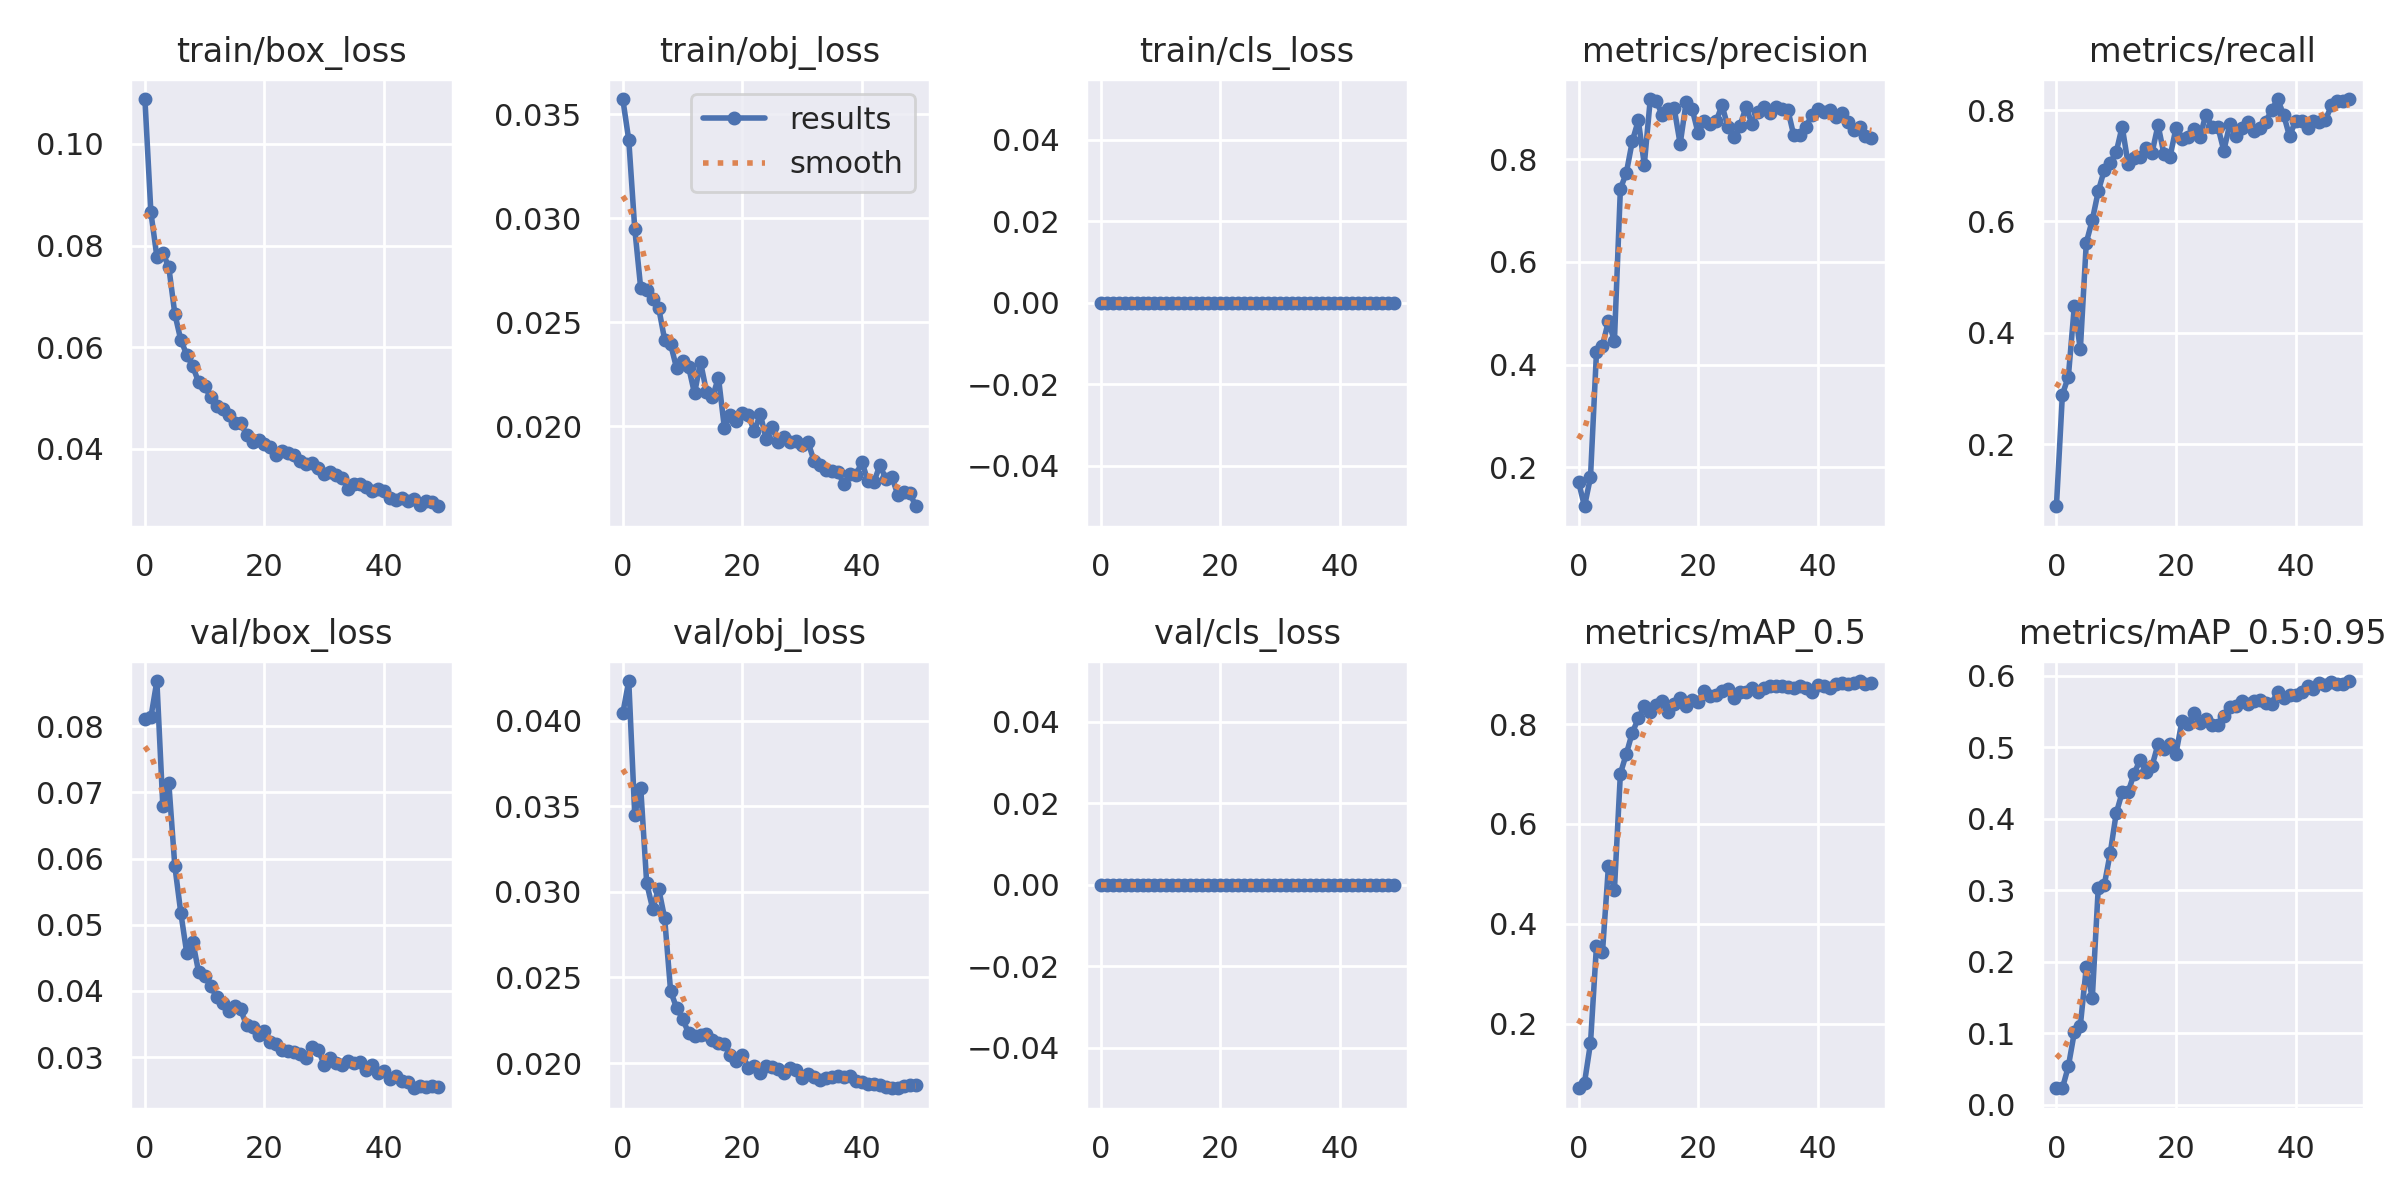


From scratch com yolov5m:


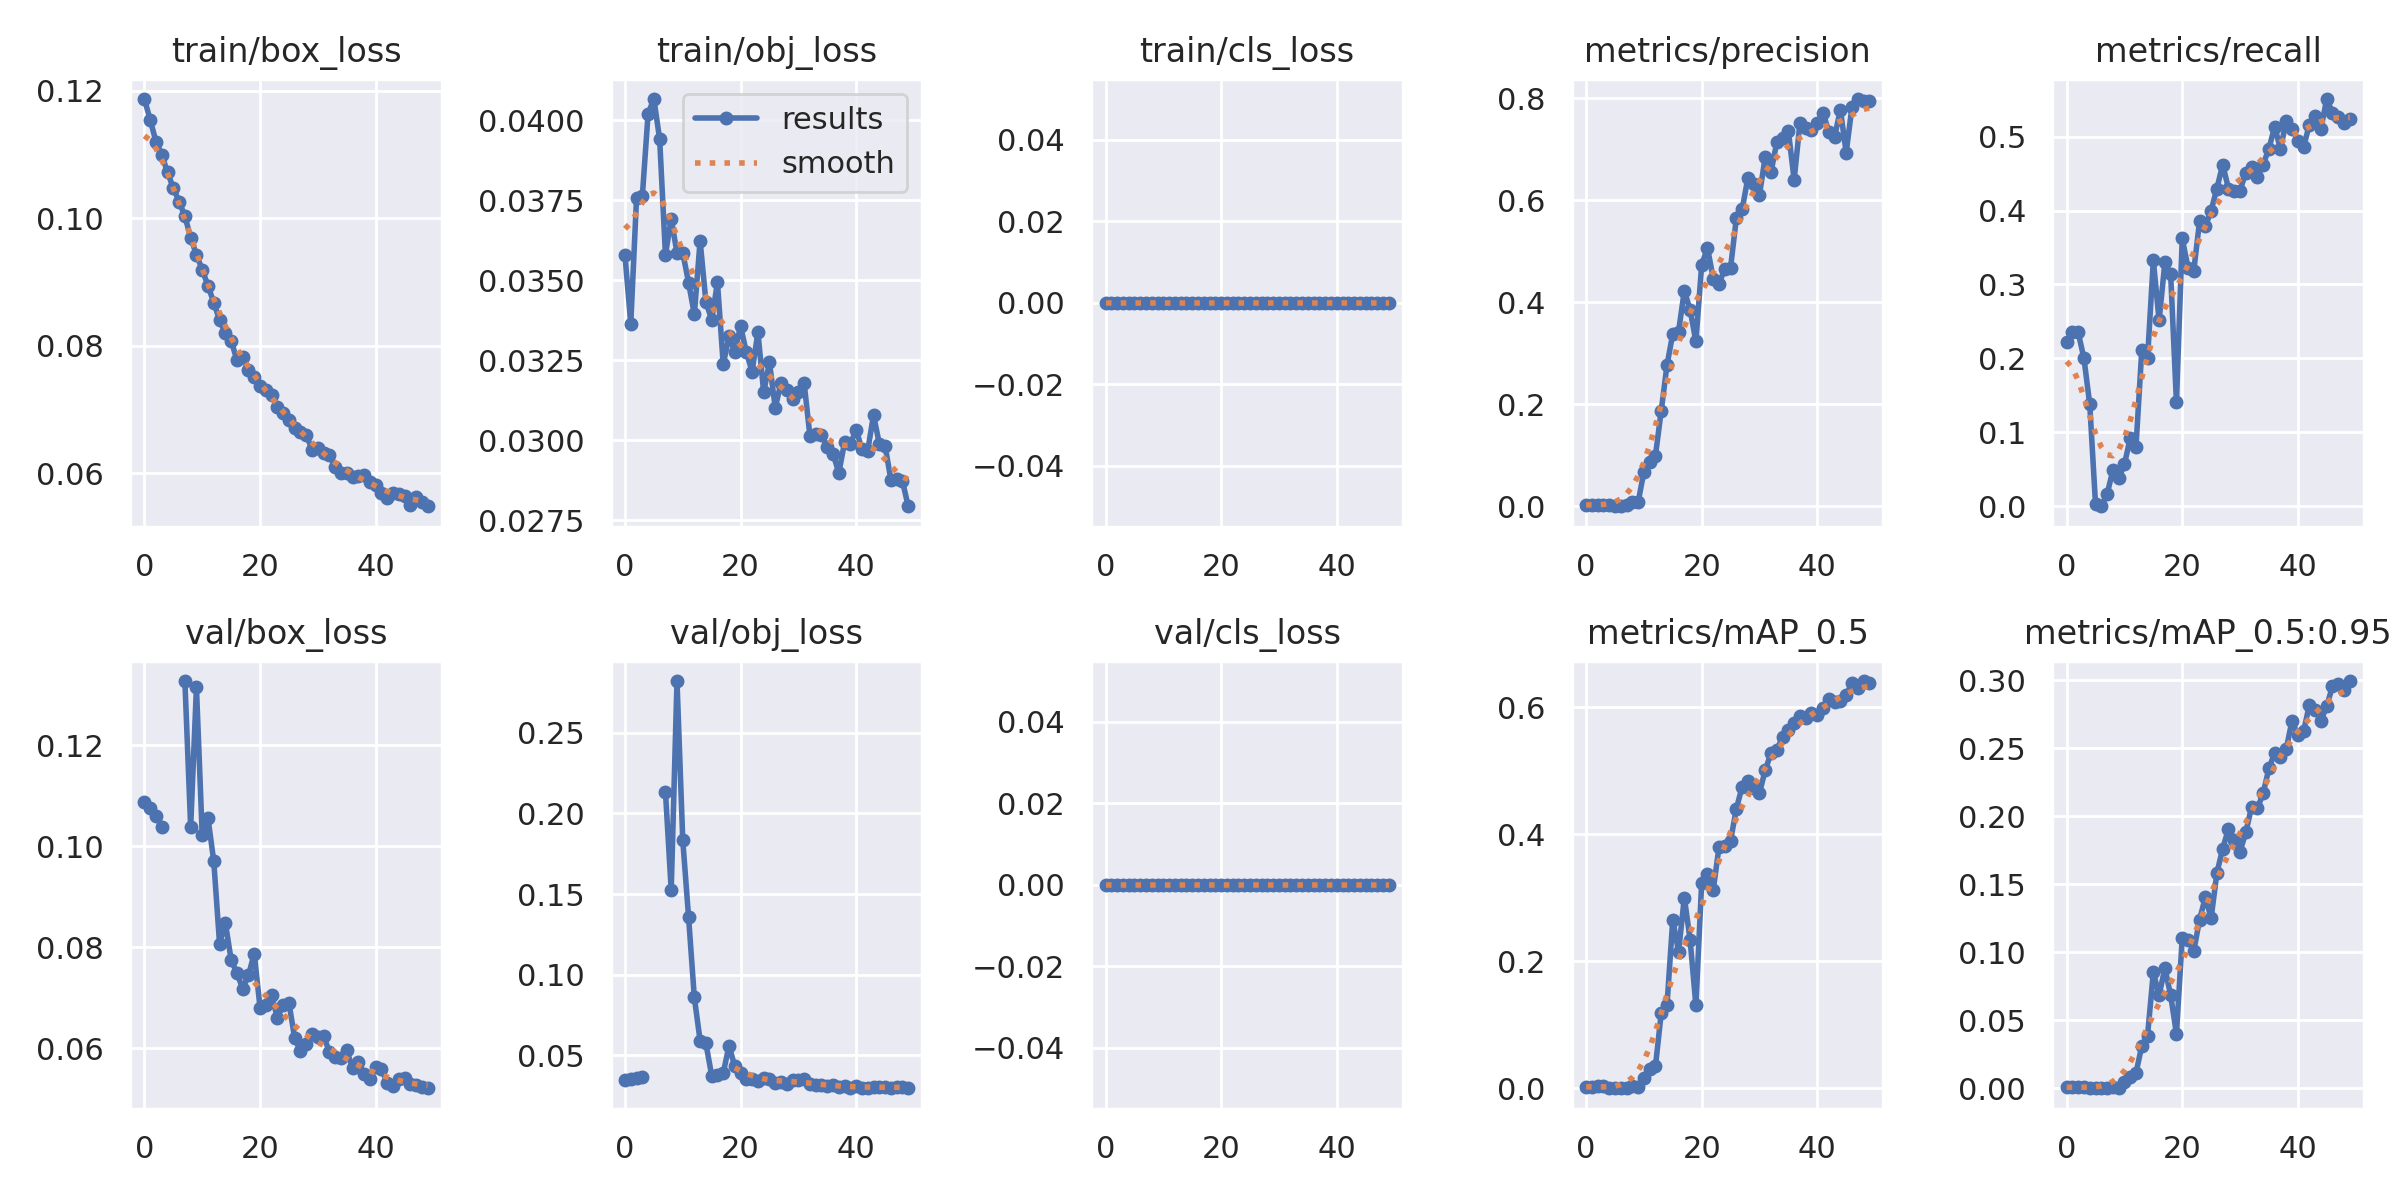

In [ ]:
from IPython.display import Image, display

# Caminhos para os gráficos salvos
result_paths = [
    '/content/gdrive/MyDrive/Assignment2/YOLO/yolov5/runs/train/exp/results.png',  # Pre-trained com yolov5m
    '/content/gdrive/MyDrive/Assignment2/YOLO/yolov5/runs/train/exp2/results.png'  # From scratch com yolov5m
]

# Definir um tamanho de largura (em pixels) para as imagens
image_width = 600  # Ajuste conforme necessário

# Exibir gráficos
print("Pre-trained com yolov5m:")
display(Image(filename=result_paths[0], width=image_width))

print("\nFrom scratch com yolov5m:")
display(Image(filename=result_paths[1], width=image_width))
